# Abstract

The purpose of this notebook is to introduce some of the basic tools that we will need to develop optimal risk retention frontiers.




<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/OpenActTextDev/ConstructPortfolio/blob/main/Notebooks/BasicTools.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
</table>





##  Reminders

Start by going to "Runtime", select "Change Runtime Type", ensure that "R" is selected, and click "Save".

You can make changes to a Colab notebook, and they will persist for as long as you keep your browser tab open. But once you close it, the changes will be lost. To avoid this, make sure you save a copy of the notebook to your Google Drive by selecting File → “Save a copy in Drive”.

## Load Libraries

As is the custom with Jupyter notebooks, we start by loading some libraries that are going to be helpful. In the following code, we also indicate where the libraries are needed with comments.

In [35]:
system('sudo apt-get update && sudo apt-get install -y libgsl-dev')
install.packages(c("actuar", "copula"))
library(actuar)
library(copula)
install.packages("alabama")
library(alabama)

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



#  Inverse Transform Method

With the sequence of uniform random numbers, we next transform them to a distribution of interest, say $F$. A prominent technique is the *inverse transform method*, defined as
$$
X_i=F^{-1}\left( U_i \right) .
$$
Here, recall from Section 4.1.1 that we introduced the inverse of the distribution function, $F^{-1}$, and referred to it also as the *quantile function*`. Specifically, it is defined to be
$$
F^{-1}(y) = \inf_x ~ \{ F(x) \ge y \} .
$$
Recall that $\inf$ stands for *infimum* or the *greatest lower bound*. It is essentially the smallest value of *x* that satisfies the inequality $\{F(x) \ge y\}$. The result is that the sequence {$X_{i}$} is *iid* with distribution function $F$ if the {$U_i$} are *iid* with uniform on $(0,1)$ distribution function.


**Example** Simulating a Gamma Random Variable.

Here is some code to simulate a gamma random variable twice

*  Using the Inverse Transform Method
*  Using a direct method, calling the function `rgamma` (the "r" stands for random).

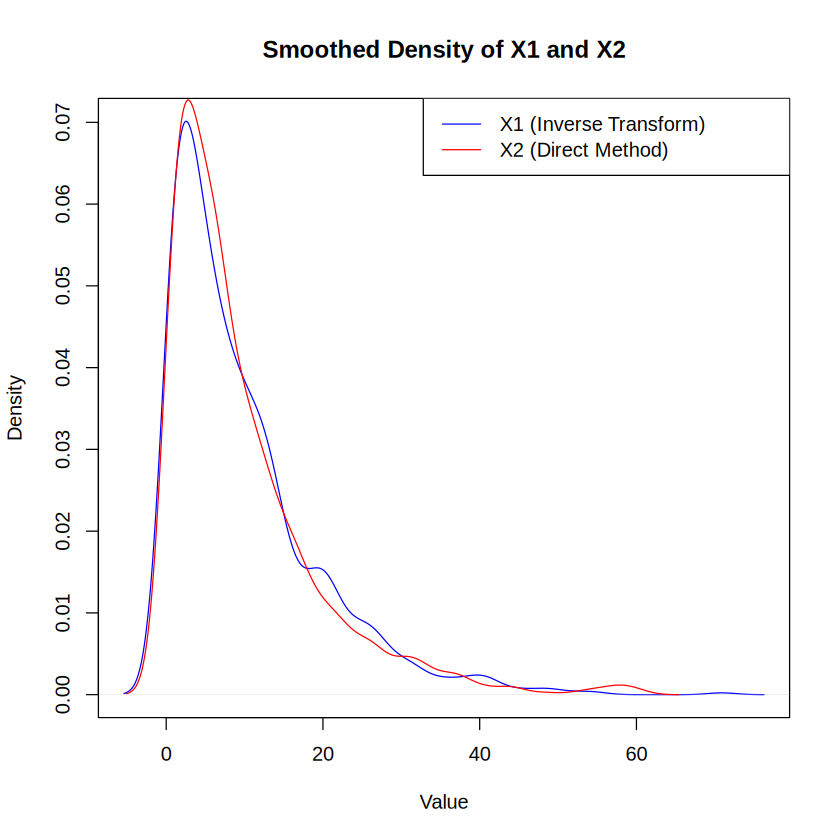

In [36]:
set.seed(2026)
nsim = 1000
#  Marginal Distribution Parmeters
risk1shape <- 1
risk1scale <- 10
#  Generate Uniform [0,1] random variables
U <- runif(nsim)
#  Inverse Transform Method
X1 <- qgamma(p=U,shape = risk1shape, scale = risk1scale)
#  Direct Method
X2 <- rgamma(nsim,shape = risk1shape, scale = risk1scale)
#  Compare the two distributions
plot(density(X1), col='blue', main='Smoothed Density of X1 and X2', xlab='Value', ylab='Density')
lines(density(X2), col='red')
legend('topright', legend=c('X1 (Inverse Transform)', 'X2 (Direct Method)'), col=c('blue', 'red'), lty=1)

**Experiment with the code.** Try different shape and scale parameters, different number of simulations, different distributions.

**Summarize a Variable**

In [37]:
#Function to Summarize a Random Variable
alpha = 0.80
SumStats.fct <- function(X){
  meanX     <- mean( X)
  stddevX    <- sd(X)
  VaR       <- as.numeric(quantile(X, prob = alpha, na.rm = TRUE))
  ES        <- as.numeric(VaR   + mean(pmax(X - VaR,   0)) /(1-alpha) )
  return( c(meanX, stddevX, VaR, ES) )
}
round(SumStats.fct(X1), digits = 4)
round(SumStats.fct(X2), digits = 4)

[1]  9.8105  9.5115 15.5353 25.3001

[1]  9.6470  9.6825 15.2568 25.1939

# Simulate Dependent Variables

Let's illustrate how to simulate dependent variables. In the following code,

*  X1 is a gamma distributed variable
*  X2 is pareto distributed (using the `actuar` package) for the marginal distribution.

The code shows the simulated data to be correlated (although you should look at the spearman, not the default Pearson).

Because X1 is a medium tail and X2 is a long-tail distribution, you will not get too many insights with the plots....

[1] 0.07269005

[1] 0.2933615

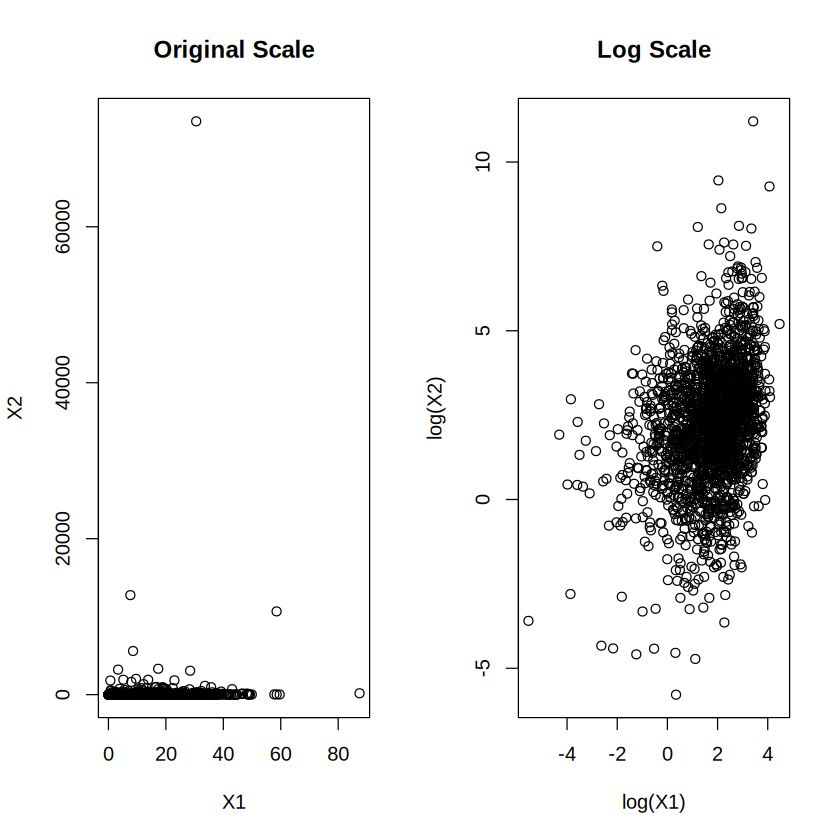

In [38]:
# Packages
#library("actuar") ; library("copula")
# Set Simulation Parameters
nsim <- 2000
set.seed(202020)
# Marginal distribution parameters
risk1shape <- 1 ;
risk1scale <- 10
risk2shape <- 1 ;
risk2scale <- 10
# Normal, or Gaussian, Copula
norm.cop <- copula::normalCopula(param=0.3, dim = 2,'dispstr' ="un")
UCop <- copula::rCopula(nsim, norm.cop)
# Marginal Distributions
X1 <- qgamma(p=UCop[,1],shape = risk1shape, scale = risk1scale)
X2 <- actuar::qpareto(p=(UCop[,2]),shape = risk2shape,
scale = risk2scale)
cor (X1, X2)
cor (X1, X2, method = "spearman")

# Plot side-by-side
par(mfrow=c(1, 2)) # 1 row, 2 columns
plot(X1, X2, main='Original Scale', xlab='X1', ylab='X2')
plot(log(X1), log(X2), main='Log Scale', xlab='log(X1)', ylab='log(X2)')
par(mfrow=c(1, 1)) # Reset plot layout

Try changing the marginal parameters and the dependence parameter `param=0.3`.

### Risk Retention Functions

Here is some code for two basic risk retention functions, the quota share and the excess of loss.

In [39]:
# Risk Retention Function
g0_XL <- function(u1,u2){
         S <- pmin(X1,u1) + pmin(X2,u2)
         return( S )
         }
g0_QS <- function(c1,c2){
         S <- X1 * c1 + X2 * c2
         return( S )
         }
round(SumStats.fct( g0_XL( u1=100, u2 = 30) ), digits = 4)
round(SumStats.fct( g0_QS( c1=0.1, c2 = 0.5) ), digits = 4)
alpha = 0.95
round(SumStats.fct( g0_XL( u1=100, u2 = 30) ), digits = 4)
round(SumStats.fct( g0_QS( c1=0.1, c2 = 0.5) ), digits = 4)

[1] 23.7346 16.7728 38.0551 49.3091

[1]  49.5254 849.4072  19.4415 224.3299

[1] 23.7346 16.7728 54.2432 63.0806

[1]  49.5254 849.4072  77.8663 790.2816

The summary statistics provide a simple way to compare these two distributions. You might try playing with the retention parameters so that the mean is about the same. How would you interpret that?

You might try plotting these two distributions to compare their shapes and interpret...

# General Constrained Optimization Approach


### Optimization with `alabama::auglag`

We will use the `auglag` function for general constrained optimization. It requires:

*   An objective function (`fn`) to minimize.
    *   Optionally, a gradient function for `fn` (`gr`).
*   An inequality constraint function (`hin`) where `hin(x) >= 0`.
    *   Optionally, a gradient function for `hin` (`jac_hin`).
*   An equality constraint function (`heq`) where `heq(x) == 0`.
    *   Optionally, a gradient function for `heq` (`jac_heq`).

Our problem is:

*   **Minimize**: $RM[g({\bf X}; \boldsymbol \theta)]$ (uncertainty of retained risks)
*   **Subject to**: $RTC(\boldsymbol \theta) \le RTC_{max}$ (budget constraint)
*   **Subject to**: $\theta_j \ge 0 $ for all $j$ (non-negative weights)

**Notes:**

*  You need to provide starting values for this approach.
*  We will not use the equality constraints for this application.
*  To simplify things, we will not use gradients of the objective nor constraint functions
   *  `auglag` will compute numerical approximations.
   *  Usually good enough although run times for optimization are typically a bit slower/

## Code for a Single Optimization Run

In [40]:
#  Code for a Single Maximal Retained Cost
#install.packages("alabama")
#library(alabama)

meanSum = mean( g0_XL( u1=Inf, u2 = Inf) )
#RTCmax = 0.5 * meanSum
RTCmax = 0.1 * meanSum
print(paste0("RTCmax is ", round(RTCmax , digits = 3)))

# Objective function to minimize standard deviation
eval_f <- function(par, ...) {
  u1 <- par[1]
  u2 <- par[2]
  SumStats.fct( g0_XL( u1, u2 ) )[4]
}

# Inequality constraints (hin >= 0)
eval_g <- function(par, ...) {
  u1 <- par[1]
  u2 <- par[2]
  RTCmax - (meanSum - SumStats.fct(  g0_XL( u1, u2 ) )[1])
}

# Initial values for u.lim_alabama (equal weights)
u_init <- c(2, 1)
print("Initial value of objective function and constraint")
round(eval_f(u_init), digits = 6)
round(eval_g(u_init) , digits = 6)

# Run the optimization
result_alabama <- auglag(
  par = u_init,
  fn = eval_f,
  hin = eval_g,
  lower = c(0, 0), # Add non-negativity constraint for u1 and u2
  control.outer=list(method="nlminb",trace=FALSE)
)

  # Extract the optimal portfolio proportions
  u.lim_alabama <- result_alabama$par

  print("Optimal portfolio upper limits using `alabama::auglag`:")
  print(round(u.lim_alabama, digits = 6))

  print("Final value of objective function and constraint")
  print(round(eval_f(u.lim_alabama), digits = 6))
  print(round(eval_g(u.lim_alabama) , digits = 6))

  round(SumStats.fct( g0_XL(u.lim_alabama[1],u.lim_alabama[2] ) ), digits = 4)



[1] "RTCmax is 10.704"
[1] "Initial value of objective function and constraint"


[1] 3

[1] -93.57707

[1] "Optimal portfolio upper limits using `alabama::auglag`:"
[1] 12531.40 52110.78
[1] "Final value of objective function and constraint"
[1] 1381.34
[1] 0


[1]   96.339 1242.598  166.143 1381.340

## Code for Several Optimization Runs - A Frontier!

RTCmax,Mean Retained Risk,Std Dev,VaR,ES,uhat_1,uhat_2
10.704,96.339,1242.598,166.143,1381.340,4653.837,52110.780
21.409,85.635,811.445,166.143,1167.254,4157.435,30702.105
32.113,74.930,477.701,166.143,953.167,2489.503,11028.015
42.817,64.226,265.447,166.143,739.080,1272.823,4231.159
53.522,53.522,140.821,166.143,524.993,540.198,1259.026
64.226,42.817,70.268,166.143,310.907,197.761,374.989
74.930,32.113,31.580,105.488,117.853,56.277,93.615
85.635,21.409,13.405,45.763,45.763,19.505,26.258
96.339,10.704,3.998,14.612,14.612,6.908,7.704


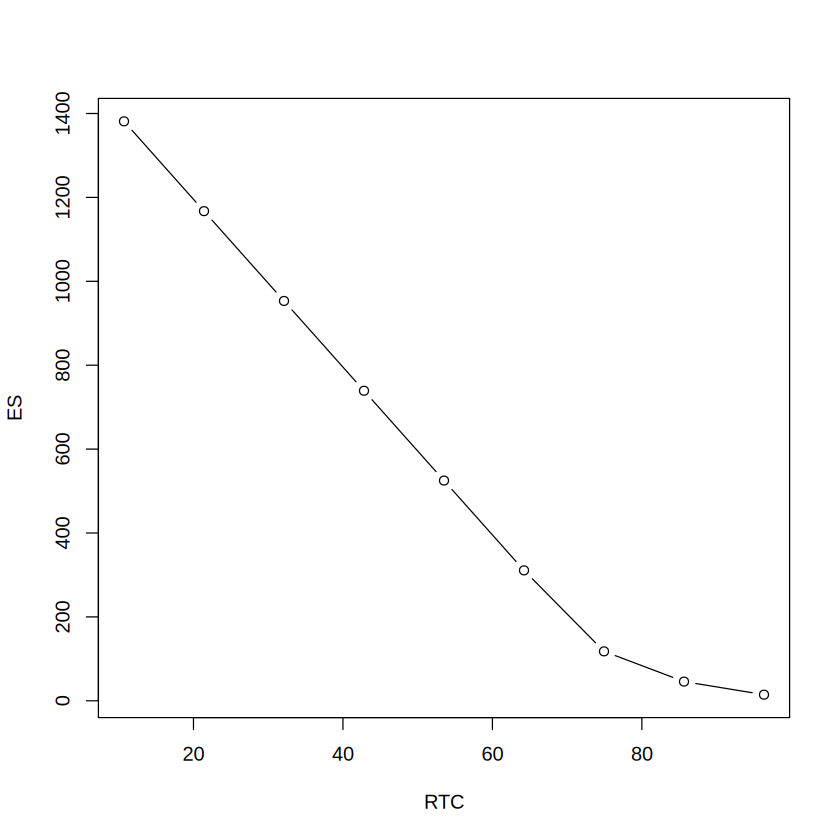

In [41]:
#  Code for a Frontier of Maximal Retained Costs

meanSum = mean( g0_XL( u1=Inf, u2 = Inf) )

# Objective function to minimize expected shortfall
eval_f <- function(par, ...) {
  u1 <- par[1]
  u2 <- par[2]
  SumStats.fct( g0_XL( u1, u2 ) )[2]
}

# Inequality constraints (hin >= 0)
eval_g <- function(par, ...) {
  u1 <- par[1]
  u2 <- par[2]
  # Constraint: RTCmax - (meanSum_retained) >= 0
  RTCmax - (meanSum - SumStats.fct(  g0_XL( u1, u2 ) )[1])
}

# Initial values for u.lim_alabama
u_init <- c(2, 1)

SumResults <- matrix(0, 9, 7)
# Loop through different RTCmax values
for (i_val in (1:9)) {
  RTCmax = (i_val/10) * meanSum

  # Run the optimization
  result_alabama <- auglag(
    par = u_init,
    fn = eval_f,
    hin = eval_g,
    lower = c(0, 0), # Add non-negativity constraint for u1 and u2
    control.outer=list(method="nlminb",trace=FALSE)
  )

  # Extract the optimal portfolio proportions
  u.lim_alabama <- result_alabama$par

  SumResults[i_val,] <- c(RTCmax, SumStats.fct( g0_XL(u.lim_alabama[1],u.lim_alabama[2] ) ), u.lim_alabama)
}
colnames(SumResults) <- c("RTCmax",
  "Mean Retained Risk", "Std Dev", "VaR", "ES", "uhat_1", "uhat_2")
round(SumResults, digits = 3)
plot(SumResults[,1], SumResults[,5], type = "b", xlab = "RTC", ylab = "ES")

# Import and Describe the Data

Some of the code in the book uses different data sets. We do not need them for this demo, but here is the code in case you wish to bring them in.

We import the data from Github course repo. At the repo "https://users.ssc.wisc.edu/~jfrees/InsurableRisks/DataDownload/", you will see other datasets.

In [42]:
download.file("https://users.ssc.wisc.edu/~jfrees/InsurableRisks/DataDownload/PropertyFundData/CLAIMLEVEL.csv", destfile = "CLAIMLEVEL.csv")
CLAIMLEVEL <- read.csv("CLAIMLEVEL.csv")

Just to make sure that data was read in properly, let's look at the structure and do a summary.

In [43]:
# List objects with details
ls.str()

alpha :  num 0.95
c_val :  num 0.9
CLAIMLEVEL : 'data.frame':	6258 obs. of  13 variables:
 $ PolicyNum    : int  120002 120003 120003 120003 120003 120003 120003 120003 120003 120003 ...
 $ ClaimNum     : int  20100192 20080726 20081656 20081657 20081656 20081656 20081656 20081656 20081656 20081656 ...
 $ Year         : int  2010 2007 2007 2007 2007 2007 2008 2009 2009 2010 ...
 $ ClaimStatus  : chr  "Closed" "Closed" "Closed" "Closed" ...
 $ Claim        : num  6839 2085 7835 3500 1480 ...
 $ Deduct       : int  1000 5000 5000 5000 5000 5000 5000 5000 5000 5000 ...
 $ EntityType   : chr  "County" "County" "County" "County" ...
 $ Description  : chr  "lightningdamage" "lightningdamageatComm.Center" "lightningdamageatwatertower" "lightningdamageatwatertower" ...
 $ CoverageGroup: chr  "BC" "BC" "BC" "BC" ...
 $ CoverageCode : chr  "VF" "VF" "VF" "VF" ...
 $ Fire5        : int  4 0 0 0 0 0 0 0 0 0 ...
 $ CountyCode   : chr  "ASH" "BAR" "BAR" "BAR" ...
 $ county       : chr  "Ashland" "Ba